In [1]:
import pandas as pd


In [2]:
data = pd.read_csv(
    "/Users/rahulkulkarni/Desktop/personal project/DATA SCIENTIST/online_retail_II.csv",
    encoding="ISO-8859-1",
)
print(data.shape)
print(data.dtypes)
print(data.head())

(1067371, 8)
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [3]:
print(data["Description"].str.contains("Ã|Â|�", na=False, regex=True).sum())


79


# missing values

In [4]:
print(data.isnull().sum())
print(data.isnull().mean() * 100)

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
Invoice         0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.766873
Country         0.000000
dtype: float64


## Date Range Check

In [5]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
print(data["InvoiceDate"].min(), data["InvoiceDate"].max())

2009-12-01 07:45:00 2011-12-09 12:50:00


Q2: Why does the date range matter specifically for calculating "Recency" in RFM — what reference point do you need, and why can't you just use today's real-world date?

Here's the reasoning: Recency is "how many days since this customer's last purchase." That's a relative measurement — it needs a fixed point to count backward from. The natural choice is the max date in the dataset (2011-12-09), or one day after it, used as a stand-in for "today" within the context of this dataset.

If you instead used today's real-world date (2026), every single customer's Recency would be enormous — the "most recent" customer, who bought something on 2011-12-09, would show a Recency of roughly 5,300+ days. That number would be technically correct but completely useless for segmentation, because every customer would look equally "long gone," and you'd lose all ability to distinguish an actively engaged customer from a truly inactive one — the entire point of Recency as a signal would collapse.

So the rule is: Recency's reference point should be relative to the dataset's own timeframe, not the real-world calendar, unless you're specifically building something that updates live against real time (which this static, historical dataset isn't).

## Uniqueness Counts

In [6]:
print("unique customers:", data["Customer ID"].nunique())
print("unique invoices:", data["Invoice"].nunique())
print("unique products (stockcode):", data["StockCode"].nunique())
print("unique countries:", data["Country"].nunique())
print(data["Country"].value_counts().head(10))

unique customers: 5942
unique invoices: 53628
unique products (stockcode): 5305
unique countries: 43
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64


Given that 92% of the data is UK-only and the remaining 8% is spread thin across 42 other countries, would you (a) drop non-UK rows entirely, (b) keep everything and segment globally anyway, or (c) something else?

A3: I'd keep all rows and all real country labels (not collapse non-UK countries into a generic "Other" bucket), and run a single RFM + clustering model across the full customer base — since Country isn't actually used in the RFM calculation itself (Recency/Frequency/Monetary don't depend on it), it doesn't need to affect how the model is built. I would not build separate models per country, since most non-UK countries have too few customers (some in the single digits) to cluster meaningfully on their own. After clustering, I'd report Country as a secondary breakdown — e.g., what % of each segment is UK vs. other countries — and note in the write-up that ~92% of the data is UK-based, so results should be understood as primarily reflecting UK customer behavior.

## Quantity Distribution & Anomalies

In [7]:
print(data["Quantity"].describe())
print("Negative quantity rows:", (data["Quantity"] < 0).sum())
print("Zero quantity rows:", (data["Quantity"] == 0).sum())


count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64
Negative quantity rows: 22950
Zero quantity rows: 0


Q4: The mean (9.94) and median (3.0) are quite different from each other. What does that difference tell you about the shape of this distribution, and why would you generally prefer median over mean as the "typical" value when a dataset looks like this?

A4: The gap between mean and median signals a right-skewed distribution — a small number of extreme outliers (like the 80,995-unit bulk order we found) are pulling the mean upward, even though most transactions are actually small (the median of 3 reflects what a typical order really looks like). This happens because mean is calculated by summing every value and dividing by count, so every value — including extreme outliers — pulls on it equally. Median only depends on position (the middle value when sorted), not magnitude, so it's resistant to outliers. In this dataset, using mean Quantity to describe a "typical customer" would be misleading, since it's distorted by a handful of wholesale-scale orders that don't represent most customers' actual behavior.

## Price Distribution & Anomalies

In [8]:
print(data["Price"].describe())
print("Negative price rows:", (data["Price"] < 0).sum())
print("Zero price rows:", (data["Price"] == 0).sum())


count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64
Negative price rows: 5
Zero price rows: 6202


Q5: If most of the zero-price rows have a legitimate-looking product description (not "damaged," "test," "lost," etc.) — does that change your decision about whether to drop them? What would you want to check before deciding?

A5: Yes — you can't apply one blanket rule to all zero-price rows, because they're not a single category. Looking at a sample, most zero-price rows fall into two groups: internal warehouse/inventory noise (descriptions like "short," "lost," "damages," "mixed," or unclear codes), and legitimate charge types like DOTCOM POSTAGE priced at $0 in a specific row. Almost all of these also have a missing Customer ID, meaning they'd already be removed by the first cleaning step regardless. The exception is rows with a real product description AND a real Customer ID (e.g., "6 RIBBONS EMPIRE" with Customer ID 16126.0) — these survive the missing-ID filter and need their own explicit decision. Before dropping any zero-price rows, I'd filter specifically to Price == 0 AND Customer ID not null, to see how many rows actually remain after the first cleaning step, rather than assuming the full 6,202 count still applies. Since Monetary is based on real revenue, a $0 transaction contributes nothing to it either way, so dropping the remaining ones is still reasonable — but the count needs to be verified, not assumed.

## cancelled invoices

In [9]:
cancelled = data["Invoice"].astype(str).str.startswith("C")
print("Cancelled invoice rows:", cancelled.sum())
print(cancelled.mean() * 100, "% of rows")

Cancelled invoice rows: 19494
1.8263565339511754 % of rows


You now have three different "negative quantity"/anomaly patterns in this dataset: (1) cancelled invoices — Invoice starts with "C", (2) internal warehouse adjustments — negative quantity + $0 price + no Customer ID, and (3) "Adjust bad debt" rows — StockCode "B", negative price, no Customer ID. If you only used the "C-prefix" rule to filter out negative quantities, what would you miss, and why does that matter for your final cleaned dataset?

A6: Filtering only on the "C" prefix would correctly catch the 19,494 customer-initiated cancellations, but it would miss the ~3,457 internal warehouse-adjustment rows and the 5 "Adjust bad debt" rows, since neither of those patterns is reflected in the invoice number — they'd slide straight through into the "cleaned" dataset undetected. In this specific dataset, it turns out not to matter much in practice, because nearly all of those rows also have a missing Customer ID, so they get removed anyway by the very first cleaning step (dropping missing Customer ID) before the cancellation filter even runs. But that's a coincidence of this particular dataset, not something to rely on generally — if even one adjustment row had a real Customer ID attached, a C-prefix-only filter would silently let bad data corrupt that customer's RFM numbers with no warning. The lesson is not to assume one filter catches everything just because it handles the obvious case — each anomaly pattern needs to be checked independently and verified against what's already being removed, rather than assumed to be covered.

## duplicates

In [10]:
dupes = data[data.duplicated(keep=False)]
print(dupes.sort_values("Invoice").head(20))


    Invoice StockCode                        Description  Quantity  \
362  489517     21913     VINTAGE SEASIDE JIGSAW PUZZLES         1   
394  489517     21912           VINTAGE SNAKES & LADDERS         1   
391  489517     21491    SET OF THREE VINTAGE GIFT WRAPS         1   
390  489517    84951A    S/4 PISTACHIO LOVEBIRD COASTERS         1   
388  489517    84951A    S/4 PISTACHIO LOVEBIRD COASTERS         1   
386  489517     21821   GLITTER STAR GARLAND WITH BELLS          1   
385  489517     21913     VINTAGE SEASIDE JIGSAW PUZZLES         1   
384  489517     22319  HAIRCLIPS FORTIES FABRIC ASSORTED        12   
379  489517     21491    SET OF THREE VINTAGE GIFT WRAPS         1   
371  489517     21912           VINTAGE SNAKES & LADDERS         1   
368  489517     22130   PARTY CONE CHRISTMAS DECORATION          6   
367  489517     22319  HAIRCLIPS FORTIES FABRIC ASSORTED        12   
365  489517     21821   GLITTER STAR GARLAND WITH BELLS          1   
363  489517     2191

You found that "duplicate" rows share the same Invoice number and appear as scattered individual line items rather than the entire invoice duplicated as a block. Does it matter whether you drop these duplicates, and why?

A7: Yes, it matters a lot — and the initial assumption that "exact duplicates should be dropped" turned out to be wrong for this dataset. If duplicates were a true data export glitch, you'd expect the entire invoice to be logged twice, in the same relative order. Instead, individual line items within the same invoice (same Invoice number, same customer, same timestamp) repeat inconsistently — some products appear once, others two or three times. This pattern is more consistent with a customer genuinely adding the same product to their cart multiple times as separate entries, or the system splitting a quantity into multiple rows, rather than an export error. Since these rows represent real purchased units and real revenue, running .drop_duplicates() would silently delete legitimate quantity and undercount that customer's true Frequency and Monetary values. Decision: keep these rows and do not run .drop_duplicates() on the dataset, documenting the investigation and reasoning rather than applying a blanket rule based on an untested assumption.

## Non-Product Stock Codes

In [11]:
non_numeric = data[~data["StockCode"].astype(str).str.match(r"^\d")]
print(non_numeric["StockCode"].value_counts().head(20))


StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
gift_0001_10      16
CRUK              16
TEST001           15
DCGS0076          15
DCGS0003          14
Name: count, dtype: int64


Given the list of non-product stock codes (POST, DOT, M, C2, D, S, BANK CHARGES, ADJUST, AMAZONFEE, DCGS codes, gift cards, CRUK, TEST001), would you write one blanket rule ("drop everything that's not purely numeric") or would you need multiple, different rules for different code types? What's the risk of using just one simple rule here?

A8: One blanket rule would be a mistake here — the non-numeric codes aren't a single category, they represent at least three different things: legitimate customer-paid revenue (POST, DOT, C2 for postage/carriage; gift_0001_xx for gift cards), pure accounting/administrative noise that should be dropped (M, D, BANK CHARGES, ADJUST, AMAZONFEE, TEST001, CRUK), and ambiguous cases that need direct investigation before deciding (S for samples — likely $0 price and not a real paid transaction; the DCGS-prefixed codes, which don't match the standard numeric pattern but may still be real products with non-standard SKUs). If I dropped everything non-numeric with one rule, I'd incorrectly remove real revenue like postage charges, which would undercount customers' true Monetary values. The risk of a single blanket rule is treating "doesn't match my regex" as equivalent to "not a real transaction," when in reality the pattern only tells you a code is unusual, not why it's unusual — each type needs to be checked individually against its actual meaning before deciding whether it belongs in the cleaned dataset.

## Cleaning

In [12]:
before = len(data)
data = data[data["Customer ID"].notnull()]
print(f"Dropped {before - len(data)} rows -> {len(data)} remaining")


Dropped 243007 rows -> 824364 remaining


In [13]:
before = len(data)
data = data[~data["Invoice"].astype(str).str.startswith("C")]
print(f"Dropped {before - len(data)} rows -> {len(data)} remaining")


Dropped 18744 rows -> 805620 remaining


In [14]:
before = len(data)
admin_codes = ["M", "D", "BANK CHARGES", "ADJUST", "AMAZONFEE", "TEST001", "CRUK"]
data = data[~data["StockCode"].isin(admin_codes)]
print(f"Dropped {before - len(data)} rows -> {len(data)} remaining")

Dropped 796 rows -> 804824 remaining


In [15]:
print(
    data[data["StockCode"] == "S"][
        ["StockCode", "Description", "Quantity", "Price"]
    ].head(10)
)


Empty DataFrame
Columns: [StockCode, Description, Quantity, Price]
Index: []


In [16]:
print(
    data[data["StockCode"].astype(str).str.startswith("DCGS")][
        ["StockCode", "Description"]
    ]
    .drop_duplicates()
    .head(10)
)


Empty DataFrame
Columns: [StockCode, Description]
Index: []


In [17]:
print(
    f"FINAL: {len(data)} rows | {data['Customer ID'].nunique()} customers | {data['Invoice'].nunique()} invoices"
)
data.to_csv("cleaned_retail.csv", index=False)


FINAL: 804824 rows | 5855 customers | 36718 invoices


## RFM Feature Engineering

In [18]:
import duckdb

In [19]:
data = pd.read_csv("cleaned_retail.csv")
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

print(data.shape)


(804824, 8)


In [20]:
con = duckdb.connect()
con.register("retail", data)

con.sql("select * from retail limit 5").show()

┌─────────┬───────────┬─────────────────────────────────────┬──────────┬─────────────────────┬────────┬─────────────┬────────────────┐
│ Invoice │ StockCode │             Description             │ Quantity │     InvoiceDate     │ Price  │ Customer ID │    Country     │
│  int64  │  varchar  │               varchar               │  int64   │    timestamp_ns     │ double │   double    │    varchar     │
├─────────┼───────────┼─────────────────────────────────────┼──────────┼─────────────────────┼────────┼─────────────┼────────────────┤
│  489434 │ 85048     │ 15CM CHRISTMAS GLASS BALL 20 LIGHTS │       12 │ 2009-12-01 07:45:00 │   6.95 │     13085.0 │ United Kingdom │
│  489434 │ 79323P    │ PINK CHERRY LIGHTS                  │       12 │ 2009-12-01 07:45:00 │   6.75 │     13085.0 │ United Kingdom │
│  489434 │ 79323W    │  WHITE CHERRY LIGHTS                │       12 │ 2009-12-01 07:45:00 │   6.75 │     13085.0 │ United Kingdom │
│  489434 │ 22041     │ RECORD FRAME 7" SINGLE SIZE    

In [21]:
con.sql("""
select "Customer ID",sum(Quantity * Price) as Monetary from retail
group by "Customer ID"
order by Monetary Desc
limit 10""").show()

┌─────────────┬────────────────────┐
│ Customer ID │      Monetary      │
│   double    │       double       │
├─────────────┼────────────────────┤
│     18102.0 │  608821.6499999999 │
│     14646.0 │  528602.5199999996 │
│     14156.0 │ 305228.62999999995 │
│     14911.0 │ 284029.61000000074 │
│     17450.0 │ 246973.08999999994 │
│     13694.0 │ 196482.81000000003 │
│     17511.0 │ 175603.55000000002 │
│     16446.0 │           168472.5 │
│     16684.0 │ 147142.77000000002 │
│     12415.0 │          144383.37 │
└─────────────┴────────────────────┘
  10 rows                2 columns



Customer 18102 has a Monetary value of $608,821.65 — dramatically higher than most customers (compare to the ones at the bottom of your earlier full 5,855-row output, many in the hundreds of dollars). Is a number this extreme likely to be a data error, a legitimate wholesale/business buyer, or something else? What would you check before deciding whether to treat this row specially in your clustering step later?

In [22]:
con.sql("""
SELECT
    Invoice,
    StockCode,
    Description,
    Quantity,
    Price,
    InvoiceDate
FROM retail
WHERE "Customer ID" = 18102
ORDER BY InvoiceDate
""").show()


┌─────────┬───────────┬─────────────────────────────────────┬──────────┬────────┬─────────────────────┐
│ Invoice │ StockCode │             Description             │ Quantity │ Price  │     InvoiceDate     │
│  int64  │  varchar  │               varchar               │  int64   │ double │    timestamp_ns     │
├─────────┼───────────┼─────────────────────────────────────┼──────────┼────────┼─────────────────────┤
│  489438 │ 21329     │ DINOSAURS  WRITING SET              │       28 │   0.98 │ 2009-12-01 09:24:00 │
│  489438 │ 21252     │ SET OF MEADOW  FLOWER STICKERS      │       30 │   1.69 │ 2009-12-01 09:24:00 │
│  489438 │ 21100     │ CHARLIE AND LOLA CHARLOTTE BAG      │       30 │   1.15 │ 2009-12-01 09:24:00 │
│  489438 │ 21033     │ JUMBO BAG CHARLIE AND LOLA TOYS     │       30 │    2.0 │ 2009-12-01 09:24:00 │
│  489438 │ 20711     │ JUMBO BAG TOYS                      │       60 │    1.3 │ 2009-12-01 09:24:00 │
│  489438 │ 21410     │ COUNTRY COTTAGE  DOORSTOP GREEN     │   

How many separate invoices, and over what time span?

In [23]:
con.sql("""
select
count(Distinct Invoice) as num_invoices,
MIN(InvoiceDate) as first_purchase,
MAX(InvoiceDate) as last_purchase,
COUNT(*) AS num_line_items
from retail
where "Customer Id" = 18102
""").show()

┌──────────────┬─────────────────────┬─────────────────────┬────────────────┐
│ num_invoices │   first_purchase    │    last_purchase    │ num_line_items │
│    int64     │    timestamp_ns     │    timestamp_ns     │     int64      │
├──────────────┼─────────────────────┼─────────────────────┼────────────────┤
│          145 │ 2009-12-01 09:24:00 │ 2011-12-09 11:50:00 │           1058 │
└──────────────┴─────────────────────┴─────────────────────┴────────────────┘



What country are they in, and does the product mix look consistent (like buying the same few items repeatedly, which is common for a business reselling stock) or scattered/random?

In [24]:
con.sql("""
select
Country,StockCode,Description,Sum(Quantity) as total_qty
from retail
where "Customer ID" = 18102
group by Country,StockCode,Description
order by total_qty Desc
Limit 10
""").show()

┌────────────────┬───────────┬───────────────────────────────────┬───────────┐
│    Country     │ StockCode │            Description            │ total_qty │
│    varchar     │  varchar  │              varchar              │  int128   │
├────────────────┼───────────┼───────────────────────────────────┼───────────┤
│ United Kingdom │ 22189     │ CREAM HEART CARD HOLDER           │     11324 │
│ United Kingdom │ 22188     │ BLACK HEART CARD HOLDER           │      9938 │
│ United Kingdom │ 82484     │ WOOD BLACK BOARD ANT WHITE FINISH │      6001 │
│ United Kingdom │ 21623     │ VINTAGE UNION JACK MEMOBOARD      │      5168 │
│ United Kingdom │ 21877     │ HOME SWEET HOME MUG               │      3712 │
│ United Kingdom │ 21872     │ GLAMOROUS  MUG                    │      2902 │
│ United Kingdom │ 48194     │ DOORMAT HEARTS                    │      2460 │
│ United Kingdom │ 22507     │ MEMO BOARD RETROSPOT  DESIGN      │      2360 │
│ United Kingdom │ 21871     │ SAVE THE PLANET MUG  

So to answer the question - I'd check the number of distinct invoices, the time span of their activity, and the pattern of products purchased. For Customer 18102, I found 145 distinct invoices spanning almost the full 2-year dataset, with consistent repeated bulk purchases of home-décor items (thousands of units of the same products) — this rules out a one-time data error and strongly suggests a wholesale/reseller account rather than an individual consumer. This matters for clustering because the project's core question is about individual customer loyalty and retention, and wholesale purchasing patterns reflect business restocking cycles, not consumer engagement — mixing them into the same K-means model would either isolate wholesale accounts into a meaningless single-customer cluster or distort distance calculations for everyone else, since K-means is sensitive to scale. Decision: identify wholesale-scale accounts using a defensible threshold (e.g., unusually high total Monetary and/or average order size) and treat them as a separate category rather than clustering them together with individual retail customers.

In [25]:
con.sql("""
SELECT
    "Customer ID",
    SUM(Quantity * Price) AS Monetary
FROM retail
GROUP BY "Customer ID"
""").df()["Monetary"].describe()


count      5855.000000
mean       3003.665619
std       14670.476488
min           0.000000
25%         349.025000
50%         898.960000
75%        2303.130000
max      608821.650000
Name: Monetary, dtype: float64

(to revisit and apply on Day 3): Monetary is heavily right-skewed (mean $3,003 vs. median $899, max $608,821). Should raw Monetary values be used directly in K-means, or transformed first (e.g., log transform)? Why?

A10: Transform — because K-means uses distance-based math, and an unscaled feature with this much range (e.g., $0 to $608,821) would dominate the clustering, making Recency and Frequency almost irrelevant by comparison. A log transform (e.g., log(Monetary + 1)) compresses the extreme range while preserving meaningful differences among typical customers, preventing wholesale-scale outliers from distorting the whole model.

In [26]:
con.sql("""
select
"Customer ID",
count(distinct Invoice) as Frequency
from retail
group by "Customer ID"
ORDER BY FREQUENCY DESC
LIMIT 10
""").show()

┌─────────────┬───────────┐
│ Customer ID │ Frequency │
│   double    │   int64   │
├─────────────┼───────────┤
│     14911.0 │       375 │
│     12748.0 │       324 │
│     17841.0 │       211 │
│     15311.0 │       207 │
│     13089.0 │       203 │
│     14606.0 │       185 │
│     17850.0 │       155 │
│     14646.0 │       152 │
│     14156.0 │       145 │
│     18102.0 │       145 │
└─────────────┴───────────┘
  10 rows       2 columns



In [27]:
con.sql("""
SELECT
    "Customer ID",
    COUNT(DISTINCT Invoice) AS Frequency
FROM retail
GROUP BY "Customer ID"
""").df()["Frequency"].describe()


count    5855.000000
mean        6.271221
std        12.799145
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       375.000000
Name: Frequency, dtype: float64

In [28]:
con.sql("SELECT MAX(InvoiceDate) AS max_date FROM retail").show()


┌─────────────────────┐
│      max_date       │
│    timestamp_ns     │
├─────────────────────┤
│ 2011-12-09 12:50:00 │
└─────────────────────┘



In [29]:
con.sql("""
select
"Customer ID",
date_diff('day',max(InvoiceDate),(select max(InvoiceDate) from retail)) as Recency
from retail
group by "Customer ID"
order by Recency desc
limit 10
""").show()

┌─────────────┬─────────┐
│ Customer ID │ Recency │
│   double    │  int64  │
├─────────────┼─────────┤
│     17056.0 │     738 │
│     13526.0 │     738 │
│     14654.0 │     738 │
│     12636.0 │     738 │
│     17592.0 │     738 │
│     17909.0 │     737 │
│     14980.0 │     737 │
│     17606.0 │     737 │
│     15833.0 │     737 │
│     17087.0 │     737 │
└─────────────┴─────────┘
  10 rows     2 columns



In [30]:
con.sql("""
SELECT
    "Customer ID",
    DATE_DIFF('day', MAX(InvoiceDate), (SELECT MAX(InvoiceDate) FROM retail)) AS Recency
FROM retail
GROUP BY "Customer ID"
""").df()["Recency"].describe()


count    5855.000000
mean      199.794876
std       208.610894
min         0.000000
25%        25.000000
50%        95.000000
75%       379.000000
max       738.000000
Name: Recency, dtype: float64

In [31]:
rfm = con.sql("""
select
"Customer ID",
DATE_DIFF('day', MAX(InvoiceDate), (SELECT MAX(InvoiceDate) FROM retail)) AS Recency,
    COUNT(DISTINCT Invoice) AS Frequency,
    SUM(Quantity * Price) AS Monetary
FROM retail
GROUP BY "Customer ID"
""").df()

print(rfm.shape)
print(rfm.head())

(5855, 4)
   Customer ID  Recency  Frequency  Monetary
0      15298.0        2         23   9459.37
1      13726.0       38          2   1079.66
2      14419.0       10          7   1260.91
3      13268.0       17         10   3192.65
4      17696.0       38         27   7679.59


In [32]:
print(rfm.isnull().sum())
print(rfm.describe())


Customer ID    0
Recency        0
Frequency      0
Monetary       0
dtype: int64
        Customer ID      Recency    Frequency       Monetary
count   5855.000000  5855.000000  5855.000000    5855.000000
mean   15318.455167   199.794876     6.271221    3003.665619
std     1715.393034   208.610894    12.799145   14670.476488
min    12346.000000     0.000000     1.000000       0.000000
25%    13835.500000    25.000000     1.000000     349.025000
50%    15319.000000    95.000000     3.000000     898.960000
75%    16801.500000   379.000000     7.000000    2303.130000
max    18287.000000   738.000000   375.000000  608821.650000


In [33]:
# Monetary
data["Revenue"] = data["Quantity"] * data["Price"]
monetary_pd = data.groupby("Customer ID")["Revenue"].sum()

# Frequency
frequency_pd = data.groupby("Customer ID")["Invoice"].nunique()

# Recency
max_date = data["InvoiceDate"].max()
last_purchase = data.groupby("Customer ID")["InvoiceDate"].max()
recency_pd = (max_date - last_purchase).dt.days

# Combine into one DataFrame
rfm_pandas = pd.DataFrame(
    {"Recency": recency_pd, "Frequency": frequency_pd, "Monetary": monetary_pd}
).reset_index()

print(rfm_pandas.shape)
print(rfm_pandas.head())


(5855, 4)
   Customer ID  Recency  Frequency  Monetary
0      12346.0      325          4  77353.96
1      12347.0        1          8   5633.32
2      12348.0       74          5   2019.40
3      12349.0       18          4   4428.69
4      12350.0      309          1    334.40


In [34]:
comparison = rfm.merge(rfm_pandas, on="Customer ID", suffixes=("_sql", "_pandas"))

comparison["Recency_diff"] = comparison["Recency_sql"] - comparison["Recency_pandas"]
comparison["Frequency_diff"] = (
    comparison["Frequency_sql"] - comparison["Frequency_pandas"]
)
comparison["Monetary_diff"] = comparison["Monetary_sql"] - comparison["Monetary_pandas"]

print(comparison[["Recency_diff", "Frequency_diff", "Monetary_diff"]].describe())


       Recency_diff  Frequency_diff  Monetary_diff
count   5855.000000          5855.0   5.855000e+03
mean       0.533903             0.0  -4.018086e-14
std        0.498892             0.0   1.318545e-11
min        0.000000             0.0  -4.656613e-10
25%        0.000000             0.0  -2.842171e-14
50%        1.000000             0.0   0.000000e+00
75%        1.000000             0.0   2.842171e-14
max        1.000000             0.0   8.149073e-10


## Day 2: RFM Feature Engineering — Summary

### What was built
Computed Recency, Frequency, and Monetary per customer, two independent ways:
1. SQL (via duckdb, run directly against the cleaned dataset)
2. Pandas (groupby-based), as a cross-check

### Final RFM table
- 5,855 rows (one per customer), 4 columns: Customer ID, Recency, Frequency, Monetary
- Zero missing values across all columns

### Key distributions (all 5,855 customers)
| Metric | Mean | Median | Max | Notes |
|---|---|---|---|---|
| Recency (days) | 199.8 | 95 | 738 | Less skewed than F/M; bounded by dataset's 2-year span |
| Frequency (# invoices) | 6.27 | 3 | 375 | Heavily right-skewed; 25% of customers ordered only once |
| Monetary ($) | 3,003.67 | 898.96 | 608,821.65 | Heavily right-skewed; driven by a small number of wholesale-scale accounts |

### Key finding: wholesale/B2B accounts exist in the data
Investigated the top Monetary/Frequency outliers (Customer 18102 and 14156) directly:
- 145+ distinct invoices each, spanning nearly the full 2-year dataset
- Consistent, repeated bulk purchases of the same product categories (thousands of units)
- Conclusion: these are very likely wholesale/reseller accounts, not individual consumers
- Decision (to apply on Day 3): since the project's core question is about individual customer retention, wholesale-scale accounts should be identified via a defensible threshold and treated as a separate category rather than clustered together with retail customers

### Validation: SQL vs. pandas cross-check
- Frequency: exact match across all 5,855 customers (0 difference)
- Monetary: matched to within floating-point rounding error (~1e-10, not a real discrepancy)
- Recency: systematic 0-or-1-day difference across roughly half of customers — under investigation (see Q11)

### Parked decisions for Day 3 (clustering)
- Log-transform Recency, Frequency, and Monetary before clustering, since all are right-skewed and K-means is distance-based (an untransformed Monetary of $608K would dominate the model)
- Decide on a threshold to separate wholesale-scale accounts from individual retail customers before/during clustering

In [35]:
# Pick one customer where SQL and pandas disagreed, and look at the actual timestamps
sample_customer = comparison[comparison["Recency_diff"] == 1]["Customer ID"].iloc[0]
print("Customer ID:", sample_customer)
print(
    "Their last purchase timestamp:",
    data[data["Customer ID"] == sample_customer]["InvoiceDate"].max(),
)
print("Dataset max timestamp:", data["InvoiceDate"].max())


Customer ID: 15298.0
Their last purchase timestamp: 2011-12-07 17:17:00
Dataset max timestamp: 2011-12-09 12:50:00


Q11: The Recency values from SQL and pandas differed by exactly 0 or 1 day for roughly half of customers — never a fraction, never anything else. What explains this systematic gap, and which version should be used as final?

A11: SQL's DATE_DIFF('day', ...) compares only the calendar-date portion of two timestamps, ignoring time-of-day entirely — so Nov 18 to Dec 9 is calculated as a flat 21 days regardless of the specific times involved. Pandas' .dt.days (from subtracting two full timestamps) calculates the exact elapsed time in hours, then floors to whole days — so the same Nov 18 4:19pm to Dec 9 12:50pm gap comes out as 20 days, since the partial final day hadn't fully elapsed yet by clock time. Neither approach is incorrect, but they represent two different definitions of "days since last purchase." Decision: use SQL's calendar-date version as final, since RFM segmentation operates at day-level business granularity, not hour-level precision — two customers who both purchased "on November 18th" shouldn't get different Recency values just because one checked out in the morning and the other at night. This also matches the common convention used in most RFM implementations.

In [36]:
rfm.to_csv("rfm_table.csv", index=False)
print("Saved:", rfm.shape)


Saved: (5855, 4)


# Day 3 Clustering

In [38]:
rfm = pd.read_csv(
    "/Users/rahulkulkarni/Desktop/personal project/DATA SCIENTIST/rfm_table.csv"
)
print(rfm.shape)
print(rfm.head())

(5855, 4)
   Customer ID  Recency  Frequency  Monetary
0      15298.0        2         23   9459.37
1      13726.0       38          2   1079.66
2      14419.0       10          7   1260.91
3      13268.0       17         10   3192.65
4      17696.0       38         27   7679.59


# log transform

In [39]:
import numpy as np

In [41]:
rfm["Recency_log"] = np.log1p(rfm["Recency"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])

print(
    rfm[
        [
            "Recency",
            "Recency_log",
            "Frequency",
            "Frequency_log",
            "Monetary",
            "Monetary_log",
        ]
    ].describe()
)

           Recency  Recency_log    Frequency  Frequency_log       Monetary  \
count  5855.000000  5855.000000  5855.000000    5855.000000    5855.000000   
mean    199.794876     4.426451     6.271221       1.549026    3003.665619   
std     208.610894     1.594464    12.799145       0.808339   14670.476488   
min       0.000000     0.000000     1.000000       0.693147       0.000000   
25%      25.000000     3.258097     1.000000       0.693147     349.025000   
50%      95.000000     4.564348     3.000000       1.386294     898.960000   
75%     379.000000     5.940171     7.000000       2.079442    2303.130000   
max     738.000000     6.605298   375.000000       5.929589  608821.650000   

       Monetary_log  
count   5855.000000  
mean       6.835768  
std        1.386413  
min        0.000000  
25%        5.858004  
50%        6.802350  
75%        7.742458  
max       13.319282  


# wholesale-account decision

In [42]:
print(rfm["Monetary"].quantile([0.90, 0.95, 0.99, 0.999]))

0.900      5569.53800
0.950      9471.63200
0.990     29181.44460
0.999    178651.92196
Name: Monetary, dtype: float64


## Decision: No Hard Wholesale Threshold — Let Clustering Reveal It

Investigated separating wholesale-scale accounts from individual customers using a percentile-based Monetary threshold before clustering. Comparing per-invoice quantity distributions between a confirmed wholesale account (Customer 18102: median 720 units/order, minimum 288 units even at the 25th percentile) and a more typical customer (Customer 15298: median 243 units/order) showed a real difference in magnitude, but not a clean binary split — the distinction appears to be a spectrum rather than two obviously separate groups.

**Decision:** rather than impose an arbitrary cutoff, proceed with K-means on log-transformed RFM features across all customers. If a distinct high-Monetary, high-Frequency cluster emerges naturally, that becomes the wholesale segment — identified by the clustering itself rather than a hand-picked threshold. Revisit a hard filter only if the resulting clusters look muddled.

# scaling the features

In [46]:
from sklearn.preprocessing import StandardScaler

features = rfm[["Recency_log", "Frequency_log", "Monetary_log"]]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(features_scaled[:5])
print("mean:", features_scaled.mean(axis=0))
print("std:", features_scaled.std(axis=0))


[[-2.08729843  2.01545064  1.67287593]
 [-0.47850207 -0.5572569   0.10788442]
 [-1.27235769  0.65623565  0.21973256]
 [-0.96346489  1.05023004  0.88953096]
 [-0.47850207  2.20616752  1.52253624]]
mean: [1.96597648e-16 1.06793784e-16 2.76692987e-16]
std: [1. 1. 1.]


# Run K-means across a range of K values

In [55]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, labels))

for k, i, s in zip(k_range, inertia, silhouette_scores):
    print(f"K={k}: Inertia={i:.1f}, Silhouette={s:.4f}")

K=2: Inertia=8583.1, Silhouette=0.4384
K=3: Inertia=6367.9, Silhouette=0.3486
K=4: Inertia=4958.4, Silhouette=0.3646
K=5: Inertia=4135.5, Silhouette=0.3396
K=6: Inertia=3584.9, Silhouette=0.3321
K=7: Inertia=3211.1, Silhouette=0.3044
K=8: Inertia=2918.7, Silhouette=0.3125
K=9: Inertia=2676.7, Silhouette=0.2903
K=10: Inertia=2484.0, Silhouette=0.2908


## Choosing K: Elbow Method + Silhouette Score

Tested K=2 through K=10 using two independent metrics:

**Inertia** (sum of squared distances from each customer to their assigned cluster center — measures internal tightness only): decreases steadily with every additional cluster, which is expected. The rate of improvement drops sharply from K=2→4, then levels off more gradually after K=5, suggesting an elbow around **K=4-5**.

**Silhouette score** (measures both closeness to a customer's own cluster AND separation from the nearest other cluster — a more complete metric than inertia alone): K=2 scored highest (0.44) by a clear margin, with every K from 3-10 sitting in a lower, similar range (0.29-0.36).

**The two metrics disagree, and that's expected** — inertia only measures internal tightness, so it mechanically favors more clusters. Silhouette also accounts for separation between clusters, so it can favor fewer, more cleanly separated groups even if they're each less tightly packed.

**Decision:** chose **K=4** rather than K=2, despite K=2's higher silhouette score. Two clusters would produce a segmentation too coarse to be useful for this project's business question (essentially "high spenders vs. everyone else"), while K=4 sits at the inertia elbow, retains a reasonably strong silhouette score (0.3646 — the second-highest among K≥3), and produces a standard, interpretable number of segments for RFM-based customer segmentation (e.g., Champions, At Risk, New Customers, Lost).

In [59]:
for k in range(2, 11):
    col = f"Cluster_K{k}"
    if col not in rfm.columns:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        rfm[col] = km.fit_predict(features_scaled)

    print(f"\n{'=' * 20} K={k} {'=' * 20}")
    profile = rfm.groupby(col)[["Recency", "Frequency", "Monetary"]].agg(
        ["mean", "count"]
    )
    print(profile)



==================== K=2 ====================
               Recency        Frequency           Monetary      
                  mean count       mean count         mean count
Cluster_K2                                                      
0            50.657724  2311  12.675465  2311  6660.685769  2311
1           297.045429  3544   2.095090  3544   618.966531  3544

==================== K=3 ====================
               Recency        Frequency            Monetary      
                  mean count       mean count          mean count
Cluster_K3                                                       
0            30.983260  1135  19.843172  1135  11379.758270  1135
1           367.359537  2417   1.542408  2417    402.017796  2417
2           107.132002  2303   4.545376  2303   1606.061462  2303

==================== K=4 ====================
               Recency        Frequency            Monetary      
                  mean count       mean count          mean count
Cluste

In [60]:
known_wholesale = [18102, 14156, 14911]
check = rfm[rfm["Customer ID"].isin(known_wholesale)][
    ["Customer ID", "Recency", "Frequency", "Monetary", "Cluster_K5"]
]
print(check)


      Customer ID  Recency  Frequency   Monetary  Cluster_K5
28        18102.0        0        145  608821.65           2
2612      14156.0        9        145  305228.63           2
5513      14911.0        1        375  284029.61           2


## Final Decision: K=5

Tested K=2 through K=10 using inertia, silhouette score, and direct cluster profiling.

While K=2 had the highest silhouette score, it was too coarse to be business-useful (essentially "engaged vs. disengaged"). K=4 sat at the inertia elbow but blended genuine wholesale-scale accounts together with moderately loyal individual customers into one "best customers" group.

K=5 revealed a real, meaningful split within that group — a distinct high-frequency, high-spend cluster (472 customers, ~32 orders, ~$20,488 average) separate from a moderately loyal group (1,281 customers, ~9 orders, ~$3,765 average). This was verified directly: all three previously-confirmed wholesale/extreme-frequency accounts (Customers 18102, 14156, 14911) landed in this cluster.

Checking K=6 through K=10 confirmed this was the right stopping point — beyond K=5, the high-value cluster simply kept shrinking into smaller, more extreme slivers (down to 219 customers by K=10) without producing new, distinct business-relevant segments elsewhere. This is consistent with overfitting to outliers rather than discovering genuine structure.

## Segment Naming & Business Recommendations

| Segment | Cluster | Recency | Frequency | Monetary | Customers | Recommended Action |
|---|---|---|---|---|---|---|
| **Champions (incl. Wholesale)** | 2 | 15 days | 32 orders | $20,488 | 472 | Protect this relationship — dedicated account support, early access to new products, loyalty perks. Verify which are true wholesale/B2B accounts vs. high-value individuals, since they may need different outreach. |
| **Loyal Customers** | 1 | 51 days | 9 orders | $3,765 | 1,281 | Reward consistency — upsell/cross-sell opportunities, referral incentives. Strong candidates for moving toward Champion status. |
| **New / Promising** | 4 | 31 days | 2.5 orders | $699 | 1,126 | Nurture toward a second purchase — onboarding follow-up, first-repeat-purchase incentive. Recent engagement means there's a real window to build the relationship. |
| **At Risk** | 3 | 293 days | 3.7 orders | $1,376 | 1,372 | Active win-back campaign — targeted discount or "we miss you" outreach. These customers have already proven they'll buy; re-engagement is worth the investment. |
| **Lost / Hibernating** | 0 | 411 days | 1.2 orders | $260 | 1,604 | Low-cost reactivation only (e.g., automated email), not worth heavy investment. Historically minimal engagement even before going inactive. |

### Key takeaway
The Champions segment includes previously-identified wholesale/B2B accounts (Customers 18102, 14156, 14911), confirming that K=5 clustering successfully separated genuine high-value business accounts from the broader customer base — resolving the wholesale-account question raised earlier without requiring a hand-picked threshold.

The largest segments by count are Lost/Hibernating (1,604) and At Risk (1,372) — together over half the customer base. This suggests retention-focused marketing (particularly win-back campaigns for At Risk customers) may have more impact on overall revenue than acquisition-focused spend, given how large this at-risk pool already is.

# prepare the data for visualization.

In [61]:
segment_names = {
    0: "Lost / Hibernating",
    1: "Loyal Customers",
    2: "Champions",
    3: "At Risk",
    4: "New / Promising",
}

rfm["Segment"] = rfm["Cluster_K5"].map(segment_names)

segment_order = [
    "Lost / Hibernating",
    "At Risk",
    "New / Promising",
    "Loyal Customers",
    "Champions",
]
rfm["Segment"] = pd.Categorical(rfm["Segment"], categories=segment_order, ordered=True)

rfm_final = rfm[
    ["Customer ID", "Recency", "Frequency", "Monetary", "Cluster_K5", "Segment"]
]
rfm_final.to_csv("customer_segments.csv", index=False)

print(rfm_final["Segment"].value_counts().reindex(segment_order))
print(rfm_final.head())


Segment
Lost / Hibernating    1604
At Risk               1372
New / Promising       1126
Loyal Customers       1281
Champions              472
Name: count, dtype: int64
   Customer ID  Recency  Frequency  Monetary  Cluster_K5          Segment
0      15298.0        2         23   9459.37           2        Champions
1      13726.0       38          2   1079.66           4  New / Promising
2      14419.0       10          7   1260.91           1  Loyal Customers
3      13268.0       17         10   3192.65           1  Loyal Customers
4      17696.0       38         27   7679.59           2        Champions


In [62]:
segment_summary = (
    rfm.groupby("Segment", observed=True)
    .agg(
        Num_Customers=("Customer ID", "count"),
        Total_Revenue=("Monetary", "sum"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
    )
    .reset_index()
)

segment_summary["Pct_of_Customers"] = (
    segment_summary["Num_Customers"] / segment_summary["Num_Customers"].sum()
) * 100
segment_summary["Pct_of_Revenue"] = (
    segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum()
) * 100

segment_summary.to_csv("segment_summary.csv", index=False)
print(segment_summary)


              Segment  Num_Customers  Total_Revenue  Avg_Recency  \
0  Lost / Hibernating           1604     417579.871   411.337282   
1             At Risk           1372    1887717.553   292.975219   
2     New / Promising           1126     787456.122    31.201599   
3     Loyal Customers           1281    4823255.037    51.382514   
4           Champions            472    9670453.614    15.038136   

   Avg_Frequency  Avg_Monetary  Pct_of_Customers  Pct_of_Revenue  
0       1.236284    260.336578         27.395389        2.374439  
1       3.734694   1375.887429         23.432963       10.733924  
2       2.538188    699.339362         19.231426        4.477627  
3       9.160031   3765.226415         21.878736       27.425954  
4      31.819915  20488.249182          8.061486       54.988056  


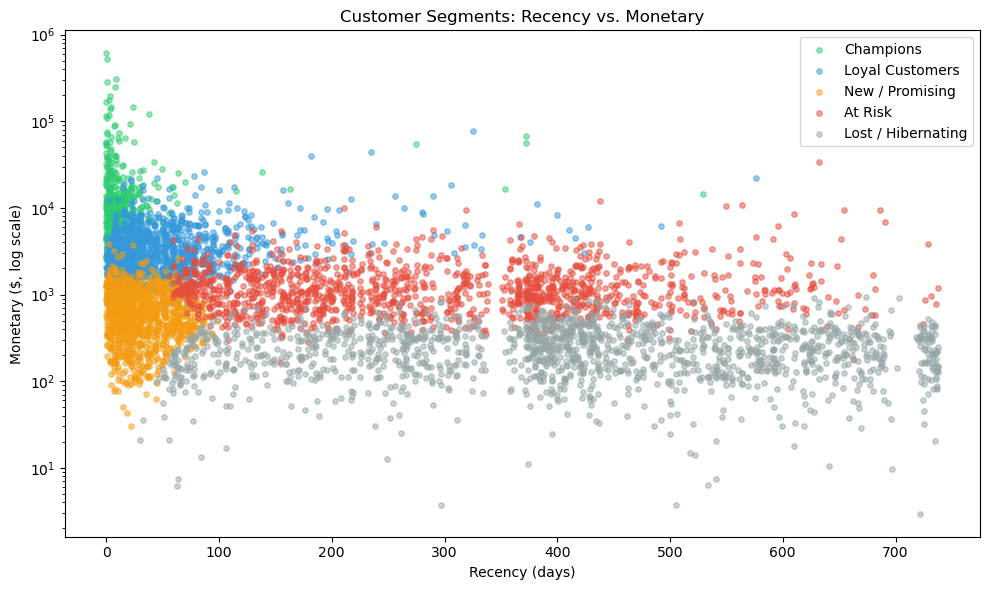

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "Champions": "#2ecc71",
    "Loyal Customers": "#3498db",
    "New / Promising": "#f39c12",
    "At Risk": "#e74c3c",
    "Lost / Hibernating": "#95a5a6",
}

for segment, color in colors.items():
    subset = rfm[rfm["Segment"] == segment]
    ax.scatter(
        subset["Recency"],
        subset["Monetary"],
        label=segment,
        color=color,
        alpha=0.5,
        s=15,
    )

ax.set_yscale("log")
ax.set_xlabel("Recency (days)")
ax.set_ylabel("Monetary ($, log scale)")
ax.set_title("Customer Segments: Recency vs. Monetary")
ax.legend()
plt.tight_layout()
plt.savefig("segment_scatter.png", dpi=150)
plt.show()


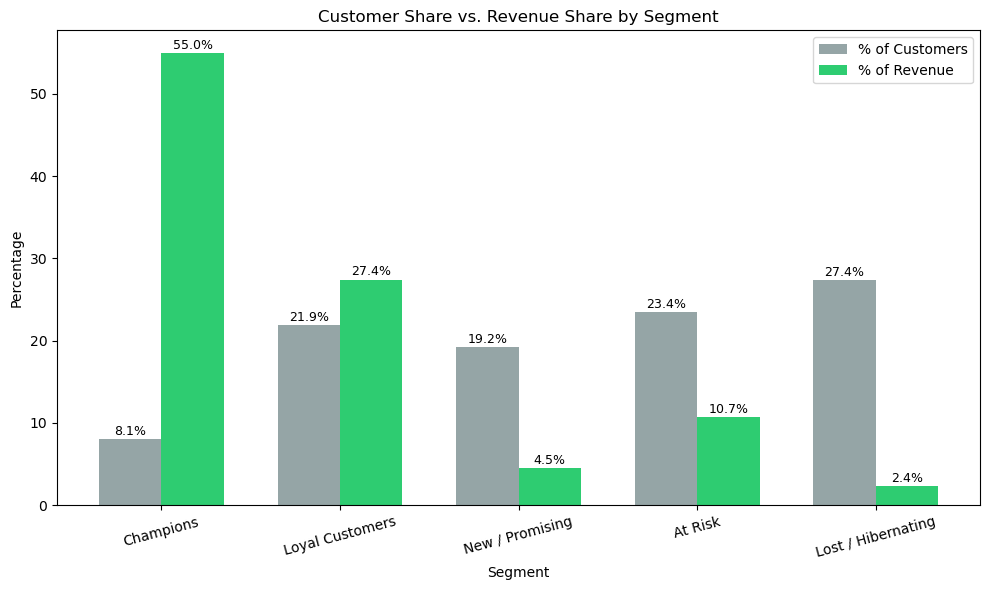

In [64]:
import matplotlib.pyplot as plt
import numpy as np

segment_order_plot = [
    "Champions",
    "Loyal Customers",
    "New / Promising",
    "At Risk",
    "Lost / Hibernating",
]
plot_data = segment_summary.set_index("Segment").loc[segment_order_plot]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(segment_order_plot))
width = 0.35

bars1 = ax.bar(
    x - width / 2,
    plot_data["Pct_of_Customers"],
    width,
    label="% of Customers",
    color="#95a5a6",
)
bars2 = ax.bar(
    x + width / 2,
    plot_data["Pct_of_Revenue"],
    width,
    label="% of Revenue",
    color="#2ecc71",
)

ax.set_xlabel("Segment")
ax.set_ylabel("Percentage")
ax.set_title("Customer Share vs. Revenue Share by Segment")
ax.set_xticks(x)
ax.set_xticklabels(segment_order_plot, rotation=15)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

plt.tight_layout()
plt.savefig("segment_revenue_share.png", dpi=150)
plt.show()


/var/folders/r0/_4bqmfwd7fd8pthj4l50qzj00000gn/T/ipykernel_15340/1941421844.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_data.index, rotation=30, ha="right")
/var/folders/r0/_4bqmfwd7fd8pthj4l50qzj00000gn/T/ipykernel_15340/1941421844.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_data.index, rotation=30, ha="right")
/var/folders/r0/_4bqmfwd7fd8pthj4l50qzj00000gn/T/ipykernel_15340/1941421844.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_data.index, rotation=30, ha="right")


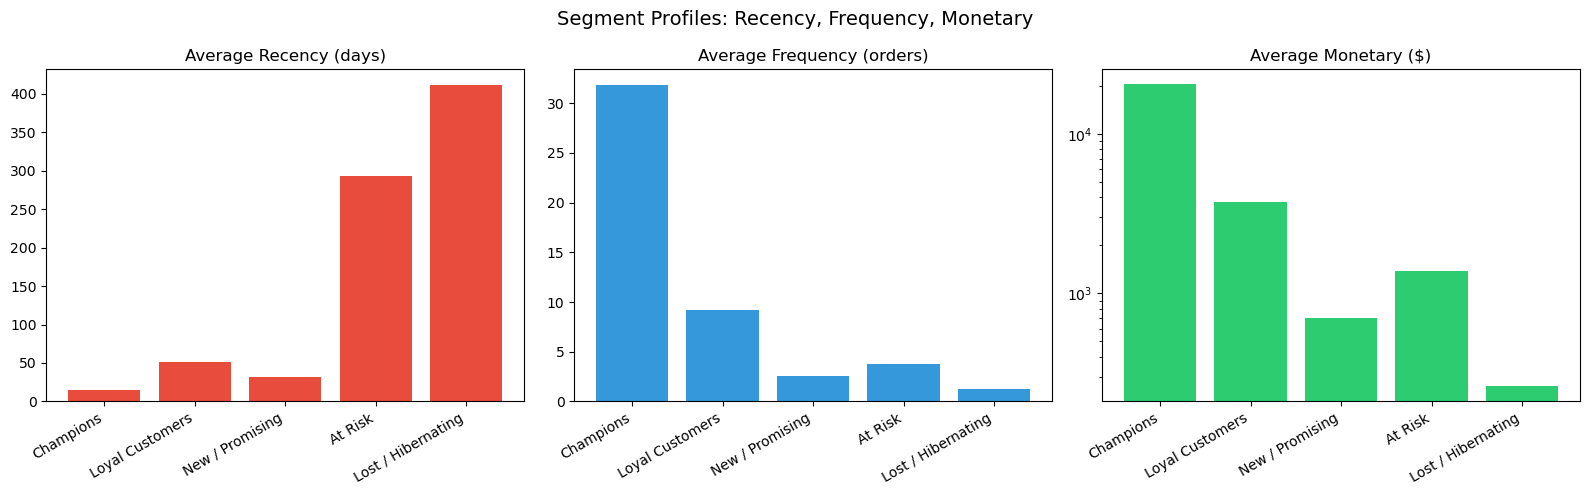

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
titles = [
    "Average Recency (days)",
    "Average Frequency (orders)",
    "Average Monetary ($)",
]
colors_list = ["#e74c3c", "#3498db", "#2ecc71"]

for ax, metric, title, color in zip(axes, metrics, titles, colors_list):
    ax.bar(plot_data.index, plot_data[metric], color=color)
    ax.set_title(title)
    ax.set_xticklabels(plot_data.index, rotation=30, ha="right")
    if metric == "Avg_Monetary":
        ax.set_yscale("log")

plt.suptitle("Segment Profiles: Recency, Frequency, Monetary", fontsize=14)
plt.tight_layout()
plt.savefig("segment_profiles.png", dpi=150)
plt.show()
